<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW2/HW2_LanguageProcessing_RNN_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [219]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt


from torchinfo import summary

In [220]:
text_sequence = """“Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.”"""

In [221]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#hyperparameters
lr = 0.01
epochs = 30
input_lengths = [10,20,30]
hidden_size = 100

device

device(type='cuda', index=0)

In [222]:
# We need to convert this text into a list of sorted indices for
print(f"Total Input Characters: {len(text_sequence)}")
sorted_text = list(sorted(set(text_sequence)))
print(f"Total Unique Characters: {len(sorted_text)}")
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}
print(ix_to_char)

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

Total Input Characters: 2393
Total Unique Characters: 47
['\n', ' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '“', '”']
{0: '\n', 1: ' ', 2: "'", 3: '(', 4: ')', 5: ',', 6: '-', 7: '.', 8: 'A', 9: 'D', 10: 'I', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'R', 17: 'S', 18: 'T', 19: 'a', 20: 'b', 21: 'c', 22: 'd', 23: 'e', 24: 'f', 25: 'g', 26: 'h', 27: 'i', 28: 'j', 29: 'k', 30: 'l', 31: 'm', 32: 'n', 33: 'o', 34: 'p', 35: 'q', 36: 'r', 37: 's', 38: 't', 39: 'u', 40: 'v', 41: 'w', 42: 'x', 43: 'y', 44: 'z', 45: '“', 46: '”'}


In [223]:
#Create Model
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(RNN, self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.rnn = nn.RNN(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)


  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.rnn(embedded)
    output = self.fc1(output[:, -1, :])
    return output

class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(LSTM,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.lstm = nn.LSTM(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.lstm(embedded)
    output = self.fc1(output[:, -1, :])
    return output

class GRU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(GRU,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.gru = nn.GRU(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.gru(embedded)
    output = self.fc1(output[:, -1, :])
    return output

In [224]:
#Splitting into train and test datasets
from sklearn.model_selection import train_test_split
def preprocess_text(text, sequence_length):
    # Preparing the dataset
    max_length = sequence_length  # Maximum length of input sequences
    X = []
    y = []
    for i in range(len(text) - max_length):
        sequence = text[i:i + max_length]
        label = text[i + max_length]
        X.append([char_to_ix[char] for char in sequence])
        y.append(char_to_ix[label])

    X = np.array(X)
    y = np.array(y)

    # Splitting the dataset into training and validation sets
    return train_test_split(X, y, test_size=0.2, random_state=1)

In [225]:
def createPlot(sequence_length, train_loss_list, val_loss_list, val_accuracy_list):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

In [258]:
def createMODELandLOSS(model):
  model = model.upper()
  valid_models = {'RNN', 'LSTM', 'GRU'}
  if model not in valid_models:
    raise ValueError(f"Invalid Type {model}. Expected one of {valid_models}")
  if(model == "RNN"):
    model = RNN(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "LSTM"):
    model = LSTM(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "GRU"):
    model = GRU(len(sorted_text), hidden_size, len(sorted_text)).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr = lr)
  return model, criterion, optimizer

In [227]:
def run(modelName):
##Data Preprocessing and converting to tensor
  for i, input_length in enumerate(input_lengths):
    model, criterion, optimizer = createMODELandLOSS(modelName)

    X_train, X_val, y_train, y_val = preprocess_text(text_sequence, input_length)

    X_train = torch.tensor(X_train, dtype=torch.long).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val = torch.tensor(X_val, dtype=torch.long).to(device)
    y_val = torch.tensor(y_val, dtype=torch.long).to(device)





    ###This is where training begins
    #Lists for storing loss and validation values
    train_loss_list = []
    val_loss_list = []
    val_accuracy_list = []


    #Create a new training loop for each input_length
    for epoch in range(epochs):
      model.train()

      optimizer.zero_grad()
      y_pred = model(X_train)  # Forward pass
      loss = criterion(y_pred, y_train)  # Compute loss
      loss.backward()  # Backward pass
      optimizer.step()  # Update model parameters

      train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                          #to the training loss list (of all epochs)


      #Here is where we evaluate the model on the current epoch
      model.eval()
      with torch.no_grad():
        val_output = model(X_val) # Take test dataset and run it through this epoch's model

        val_loss = criterion(val_output, y_val) #Find the loss

        _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

        val_accuracy = (predicted == y_val).float().mean() #Here we take each answer from out model,
                                                          #compare it to the ground truth, and find how accurate we are

        val_loss_list.append(val_loss.item())
        val_accuracy_list.append(val_accuracy.item())


        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}')

    createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)



Epoch 0, Loss: 3.9420, Val Accuracy: 0.2809, Val Loss: 3.3707
Epoch 1, Loss: 3.3684, Val Accuracy: 0.2977, Val Loss: 2.8942
Epoch 2, Loss: 2.8997, Val Accuracy: 0.2704, Val Loss: 2.6837
Epoch 3, Loss: 2.6957, Val Accuracy: 0.3187, Val Loss: 2.5825
Epoch 4, Loss: 2.5421, Val Accuracy: 0.3124, Val Loss: 2.5147
Epoch 5, Loss: 2.4333, Val Accuracy: 0.3333, Val Loss: 2.4432
Epoch 6, Loss: 2.3502, Val Accuracy: 0.3648, Val Loss: 2.3648
Epoch 7, Loss: 2.2724, Val Accuracy: 0.3753, Val Loss: 2.2973
Epoch 8, Loss: 2.2034, Val Accuracy: 0.4025, Val Loss: 2.2452
Epoch 9, Loss: 2.1399, Val Accuracy: 0.4088, Val Loss: 2.2056
Epoch 10, Loss: 2.0800, Val Accuracy: 0.4067, Val Loss: 2.1690
Epoch 11, Loss: 2.0210, Val Accuracy: 0.4214, Val Loss: 2.1275
Epoch 12, Loss: 1.9597, Val Accuracy: 0.4235, Val Loss: 2.0871
Epoch 13, Loss: 1.9019, Val Accuracy: 0.4486, Val Loss: 2.0529
Epoch 14, Loss: 1.8494, Val Accuracy: 0.4675, Val Loss: 2.0235
Epoch 15, Loss: 1.7986, Val Accuracy: 0.4864, Val Loss: 1.9985
Ep

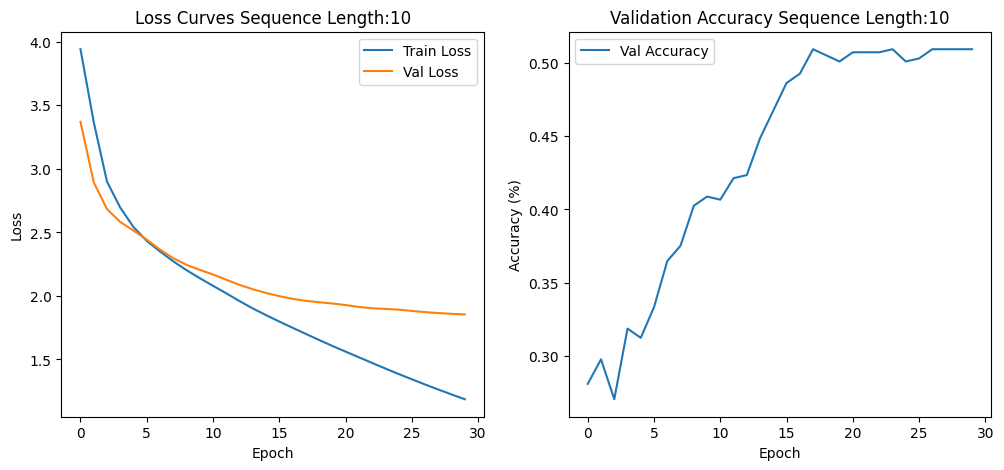

Epoch 0, Loss: 3.9295, Val Accuracy: 0.1747, Val Loss: 3.4686
Epoch 1, Loss: 3.4086, Val Accuracy: 0.2589, Val Loss: 3.0293
Epoch 2, Loss: 2.9327, Val Accuracy: 0.2442, Val Loss: 2.7565
Epoch 3, Loss: 2.6456, Val Accuracy: 0.2947, Val Loss: 2.6490
Epoch 4, Loss: 2.5078, Val Accuracy: 0.3074, Val Loss: 2.5781
Epoch 5, Loss: 2.3987, Val Accuracy: 0.3347, Val Loss: 2.5307
Epoch 6, Loss: 2.3174, Val Accuracy: 0.3284, Val Loss: 2.4901
Epoch 7, Loss: 2.2469, Val Accuracy: 0.3537, Val Loss: 2.4465
Epoch 8, Loss: 2.1754, Val Accuracy: 0.3516, Val Loss: 2.4063
Epoch 9, Loss: 2.1113, Val Accuracy: 0.3600, Val Loss: 2.3654
Epoch 10, Loss: 2.0530, Val Accuracy: 0.3621, Val Loss: 2.3199
Epoch 11, Loss: 1.9961, Val Accuracy: 0.3832, Val Loss: 2.2750
Epoch 12, Loss: 1.9422, Val Accuracy: 0.3937, Val Loss: 2.2361
Epoch 13, Loss: 1.8923, Val Accuracy: 0.4000, Val Loss: 2.2014
Epoch 14, Loss: 1.8422, Val Accuracy: 0.3958, Val Loss: 2.1703
Epoch 15, Loss: 1.7915, Val Accuracy: 0.3979, Val Loss: 2.1437
Ep

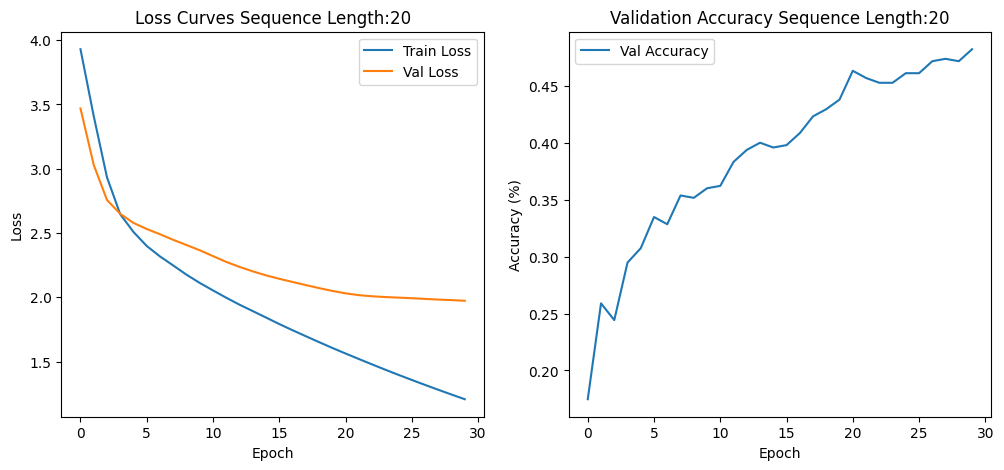

Epoch 0, Loss: 3.8965, Val Accuracy: 0.2304, Val Loss: 3.4081
Epoch 1, Loss: 3.3377, Val Accuracy: 0.2114, Val Loss: 2.9799
Epoch 2, Loss: 2.8460, Val Accuracy: 0.2051, Val Loss: 2.8281
Epoch 3, Loss: 2.6431, Val Accuracy: 0.2220, Val Loss: 2.7117
Epoch 4, Loss: 2.5138, Val Accuracy: 0.2812, Val Loss: 2.6134
Epoch 5, Loss: 2.3974, Val Accuracy: 0.3066, Val Loss: 2.5506
Epoch 6, Loss: 2.3131, Val Accuracy: 0.3087, Val Loss: 2.5104
Epoch 7, Loss: 2.2462, Val Accuracy: 0.3425, Val Loss: 2.4704
Epoch 8, Loss: 2.1771, Val Accuracy: 0.3573, Val Loss: 2.4262
Epoch 9, Loss: 2.1071, Val Accuracy: 0.3552, Val Loss: 2.3848
Epoch 10, Loss: 2.0460, Val Accuracy: 0.3805, Val Loss: 2.3498
Epoch 11, Loss: 1.9939, Val Accuracy: 0.4123, Val Loss: 2.3160
Epoch 12, Loss: 1.9401, Val Accuracy: 0.4228, Val Loss: 2.2848
Epoch 13, Loss: 1.8845, Val Accuracy: 0.4165, Val Loss: 2.2612
Epoch 14, Loss: 1.8341, Val Accuracy: 0.4249, Val Loss: 2.2422
Epoch 15, Loss: 1.7874, Val Accuracy: 0.4313, Val Loss: 2.2242
Ep

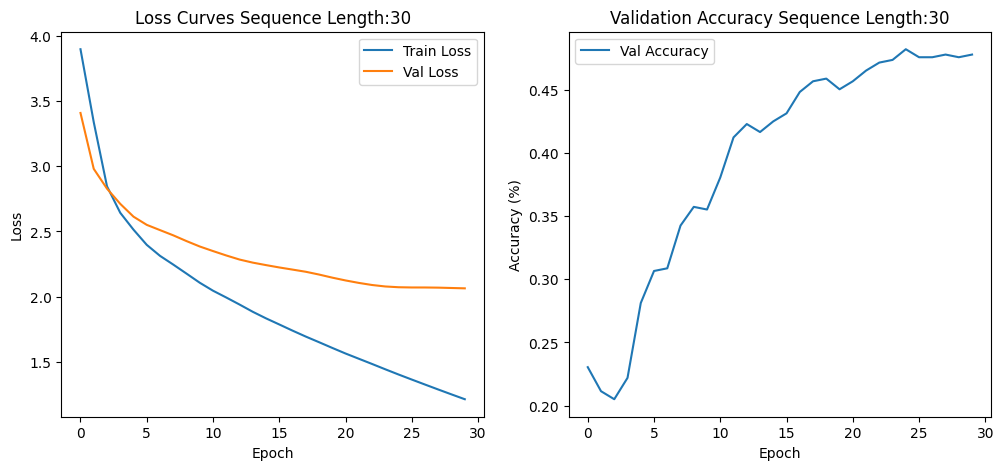

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 34]                   --
├─Embedding: 1-1                         [1, 20, 100]              3,400
├─RNN: 1-2                               [1, 20, 100]              20,200
├─Linear: 1-3                            [1, 34]                   3,434
Total params: 27,034
Trainable params: 27,034
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.11
Estimated Total Size (MB): 0.14

In [228]:
run("RNN")
summary(model, input_size = (1,20), dtypes=[torch.long])

Epoch 0, Loss: 3.8740, Val Accuracy: 0.1740, Val Loss: 3.6435
Epoch 1, Loss: 3.6394, Val Accuracy: 0.2055, Val Loss: 3.2962
Epoch 2, Loss: 3.2984, Val Accuracy: 0.1593, Val Loss: 2.9486
Epoch 3, Loss: 2.9586, Val Accuracy: 0.1950, Val Loss: 2.8115
Epoch 4, Loss: 2.8410, Val Accuracy: 0.2935, Val Loss: 2.6781
Epoch 5, Loss: 2.7135, Val Accuracy: 0.3103, Val Loss: 2.5980
Epoch 6, Loss: 2.6073, Val Accuracy: 0.3270, Val Loss: 2.5414
Epoch 7, Loss: 2.5240, Val Accuracy: 0.3417, Val Loss: 2.4818
Epoch 8, Loss: 2.4469, Val Accuracy: 0.3543, Val Loss: 2.4185
Epoch 9, Loss: 2.3722, Val Accuracy: 0.3816, Val Loss: 2.3565
Epoch 10, Loss: 2.3032, Val Accuracy: 0.3899, Val Loss: 2.3009
Epoch 11, Loss: 2.2417, Val Accuracy: 0.3836, Val Loss: 2.2533
Epoch 12, Loss: 2.1845, Val Accuracy: 0.3983, Val Loss: 2.2123
Epoch 13, Loss: 2.1289, Val Accuracy: 0.3983, Val Loss: 2.1759
Epoch 14, Loss: 2.0739, Val Accuracy: 0.4109, Val Loss: 2.1427
Epoch 15, Loss: 2.0208, Val Accuracy: 0.4130, Val Loss: 2.1143
Ep

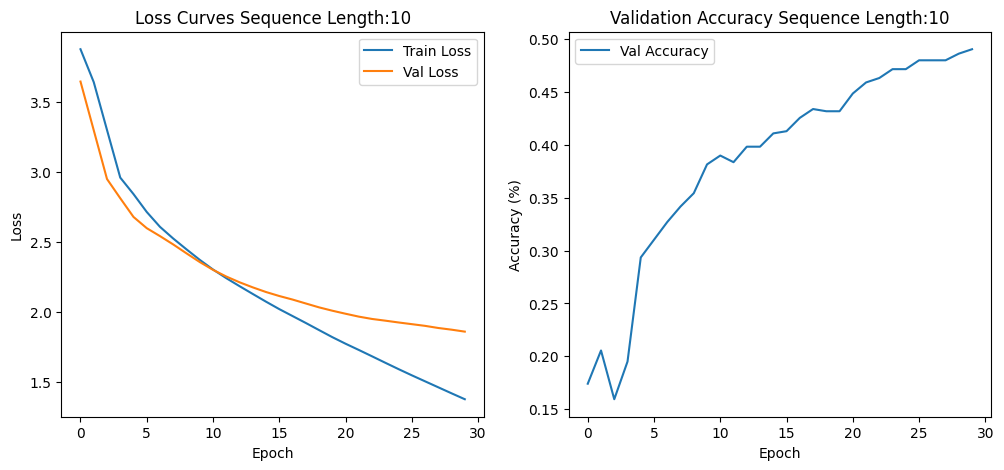

Epoch 0, Loss: 3.8771, Val Accuracy: 0.1811, Val Loss: 3.6579
Epoch 1, Loss: 3.6410, Val Accuracy: 0.2232, Val Loss: 3.3290
Epoch 2, Loss: 3.2895, Val Accuracy: 0.1389, Val Loss: 3.0156
Epoch 3, Loss: 2.9567, Val Accuracy: 0.2211, Val Loss: 2.9013
Epoch 4, Loss: 2.8181, Val Accuracy: 0.2526, Val Loss: 2.8203
Epoch 5, Loss: 2.6997, Val Accuracy: 0.2863, Val Loss: 2.7462
Epoch 6, Loss: 2.5921, Val Accuracy: 0.2968, Val Loss: 2.6814
Epoch 7, Loss: 2.5037, Val Accuracy: 0.3242, Val Loss: 2.6192
Epoch 8, Loss: 2.4233, Val Accuracy: 0.3305, Val Loss: 2.5617
Epoch 9, Loss: 2.3504, Val Accuracy: 0.3347, Val Loss: 2.5082
Epoch 10, Loss: 2.2821, Val Accuracy: 0.3453, Val Loss: 2.4573
Epoch 11, Loss: 2.2148, Val Accuracy: 0.3558, Val Loss: 2.4111
Epoch 12, Loss: 2.1499, Val Accuracy: 0.3705, Val Loss: 2.3694
Epoch 13, Loss: 2.0873, Val Accuracy: 0.3853, Val Loss: 2.3320
Epoch 14, Loss: 2.0280, Val Accuracy: 0.3958, Val Loss: 2.3011
Epoch 15, Loss: 1.9729, Val Accuracy: 0.4000, Val Loss: 2.2702
Ep

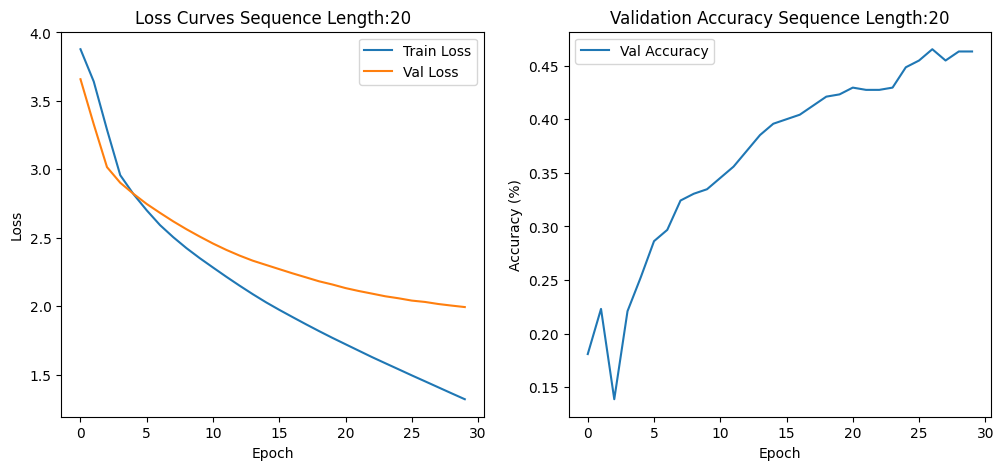

Epoch 0, Loss: 3.8571, Val Accuracy: 0.1543, Val Loss: 3.6300
Epoch 1, Loss: 3.5915, Val Accuracy: 0.1586, Val Loss: 3.2876
Epoch 2, Loss: 3.2076, Val Accuracy: 0.1268, Val Loss: 3.0638
Epoch 3, Loss: 2.9364, Val Accuracy: 0.1945, Val Loss: 2.9877
Epoch 4, Loss: 2.8334, Val Accuracy: 0.2241, Val Loss: 2.8919
Epoch 5, Loss: 2.7167, Val Accuracy: 0.2326, Val Loss: 2.8074
Epoch 6, Loss: 2.6150, Val Accuracy: 0.2452, Val Loss: 2.7335
Epoch 7, Loss: 2.5279, Val Accuracy: 0.2516, Val Loss: 2.6640
Epoch 8, Loss: 2.4473, Val Accuracy: 0.2706, Val Loss: 2.5983
Epoch 9, Loss: 2.3721, Val Accuracy: 0.3002, Val Loss: 2.5367
Epoch 10, Loss: 2.3009, Val Accuracy: 0.3488, Val Loss: 2.4792
Epoch 11, Loss: 2.2316, Val Accuracy: 0.3531, Val Loss: 2.4261
Epoch 12, Loss: 2.1645, Val Accuracy: 0.3763, Val Loss: 2.3774
Epoch 13, Loss: 2.1008, Val Accuracy: 0.3890, Val Loss: 2.3331
Epoch 14, Loss: 2.0397, Val Accuracy: 0.3975, Val Loss: 2.2942
Epoch 15, Loss: 1.9807, Val Accuracy: 0.4144, Val Loss: 2.2608
Ep

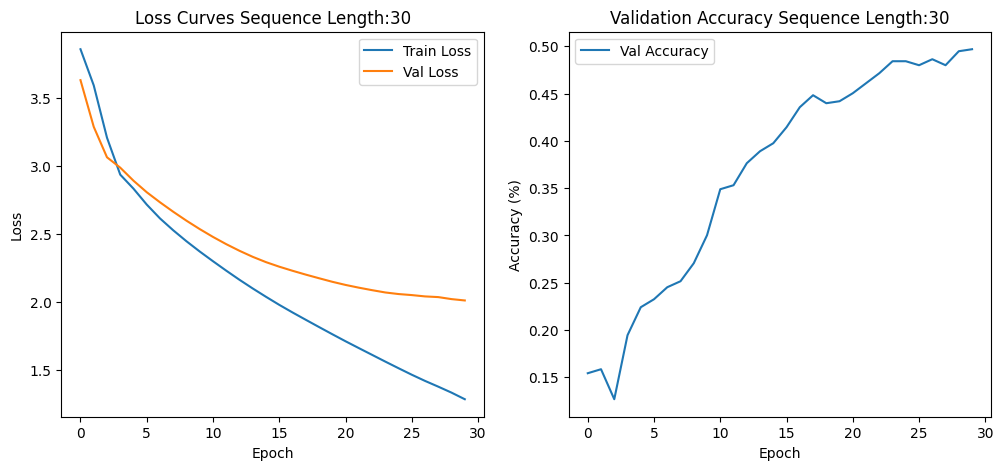

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 34]                   --
├─Embedding: 1-1                         [1, 20, 100]              3,400
├─RNN: 1-2                               [1, 20, 100]              20,200
├─Linear: 1-3                            [1, 34]                   3,434
Total params: 27,034
Trainable params: 27,034
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.11
Estimated Total Size (MB): 0.14

In [229]:
run("LSTM")
summary(model, input_size = (1,20), dtypes=[torch.long])

Epoch 0, Loss: 3.8501, Val Accuracy: 0.2222, Val Loss: 3.5510
Epoch 1, Loss: 3.5591, Val Accuracy: 0.2096, Val Loss: 3.1328
Epoch 2, Loss: 3.1504, Val Accuracy: 0.2075, Val Loss: 2.9195
Epoch 3, Loss: 2.9473, Val Accuracy: 0.2327, Val Loss: 2.8261
Epoch 4, Loss: 2.8471, Val Accuracy: 0.2977, Val Loss: 2.7432
Epoch 5, Loss: 2.7469, Val Accuracy: 0.3187, Val Loss: 2.6646
Epoch 6, Loss: 2.6512, Val Accuracy: 0.3249, Val Loss: 2.5913
Epoch 7, Loss: 2.5641, Val Accuracy: 0.3187, Val Loss: 2.5264
Epoch 8, Loss: 2.4869, Val Accuracy: 0.3291, Val Loss: 2.4690
Epoch 9, Loss: 2.4170, Val Accuracy: 0.3501, Val Loss: 2.4105
Epoch 10, Loss: 2.3490, Val Accuracy: 0.3690, Val Loss: 2.3491
Epoch 11, Loss: 2.2819, Val Accuracy: 0.3732, Val Loss: 2.2940
Epoch 12, Loss: 2.2182, Val Accuracy: 0.4004, Val Loss: 2.2492
Epoch 13, Loss: 2.1579, Val Accuracy: 0.4046, Val Loss: 2.2115
Epoch 14, Loss: 2.1021, Val Accuracy: 0.4067, Val Loss: 2.1758
Epoch 15, Loss: 2.0483, Val Accuracy: 0.4193, Val Loss: 2.1413
Ep

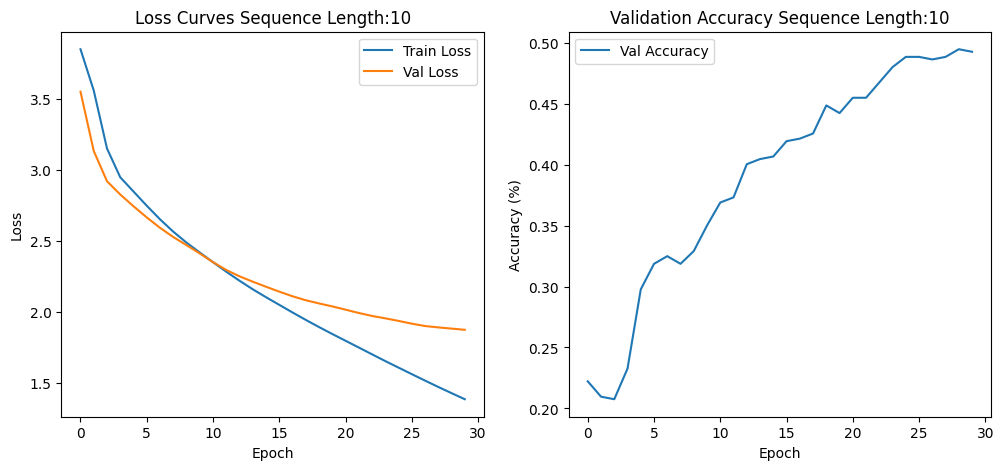

Epoch 0, Loss: 3.8523, Val Accuracy: 0.2337, Val Loss: 3.6215
Epoch 1, Loss: 3.6085, Val Accuracy: 0.2063, Val Loss: 3.2464
Epoch 2, Loss: 3.2166, Val Accuracy: 0.1474, Val Loss: 2.9713
Epoch 3, Loss: 2.9305, Val Accuracy: 0.2421, Val Loss: 2.9176
Epoch 4, Loss: 2.8505, Val Accuracy: 0.2547, Val Loss: 2.8308
Epoch 5, Loss: 2.7314, Val Accuracy: 0.2716, Val Loss: 2.7483
Epoch 6, Loss: 2.6229, Val Accuracy: 0.2842, Val Loss: 2.6851
Epoch 7, Loss: 2.5379, Val Accuracy: 0.2947, Val Loss: 2.6287
Epoch 8, Loss: 2.4613, Val Accuracy: 0.3221, Val Loss: 2.5751
Epoch 9, Loss: 2.3882, Val Accuracy: 0.3347, Val Loss: 2.5258
Epoch 10, Loss: 2.3199, Val Accuracy: 0.3453, Val Loss: 2.4810
Epoch 11, Loss: 2.2564, Val Accuracy: 0.3621, Val Loss: 2.4387
Epoch 12, Loss: 2.1964, Val Accuracy: 0.3537, Val Loss: 2.3969
Epoch 13, Loss: 2.1385, Val Accuracy: 0.3558, Val Loss: 2.3545
Epoch 14, Loss: 2.0825, Val Accuracy: 0.3726, Val Loss: 2.3142
Epoch 15, Loss: 2.0299, Val Accuracy: 0.3874, Val Loss: 2.2762
Ep

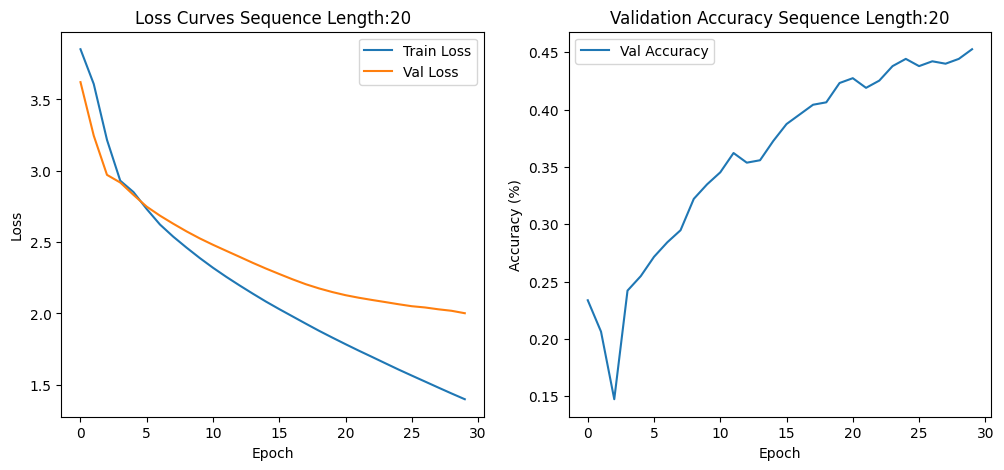

Epoch 0, Loss: 3.8524, Val Accuracy: 0.1649, Val Loss: 3.5785
Epoch 1, Loss: 3.5519, Val Accuracy: 0.1311, Val Loss: 3.1948
Epoch 2, Loss: 3.1273, Val Accuracy: 0.1226, Val Loss: 3.0614
Epoch 3, Loss: 2.9478, Val Accuracy: 0.2389, Val Loss: 2.9387
Epoch 4, Loss: 2.8269, Val Accuracy: 0.2135, Val Loss: 2.8629
Epoch 5, Loss: 2.7500, Val Accuracy: 0.2389, Val Loss: 2.7750
Epoch 6, Loss: 2.6500, Val Accuracy: 0.2304, Val Loss: 2.7000
Epoch 7, Loss: 2.5540, Val Accuracy: 0.2474, Val Loss: 2.6460
Epoch 8, Loss: 2.4777, Val Accuracy: 0.2664, Val Loss: 2.6002
Epoch 9, Loss: 2.4143, Val Accuracy: 0.2939, Val Loss: 2.5514
Epoch 10, Loss: 2.3529, Val Accuracy: 0.3277, Val Loss: 2.4992
Epoch 11, Loss: 2.2899, Val Accuracy: 0.3404, Val Loss: 2.4495
Epoch 12, Loss: 2.2277, Val Accuracy: 0.3488, Val Loss: 2.4087
Epoch 13, Loss: 2.1697, Val Accuracy: 0.3636, Val Loss: 2.3727
Epoch 14, Loss: 2.1143, Val Accuracy: 0.3763, Val Loss: 2.3367
Epoch 15, Loss: 2.0594, Val Accuracy: 0.3932, Val Loss: 2.3063
Ep

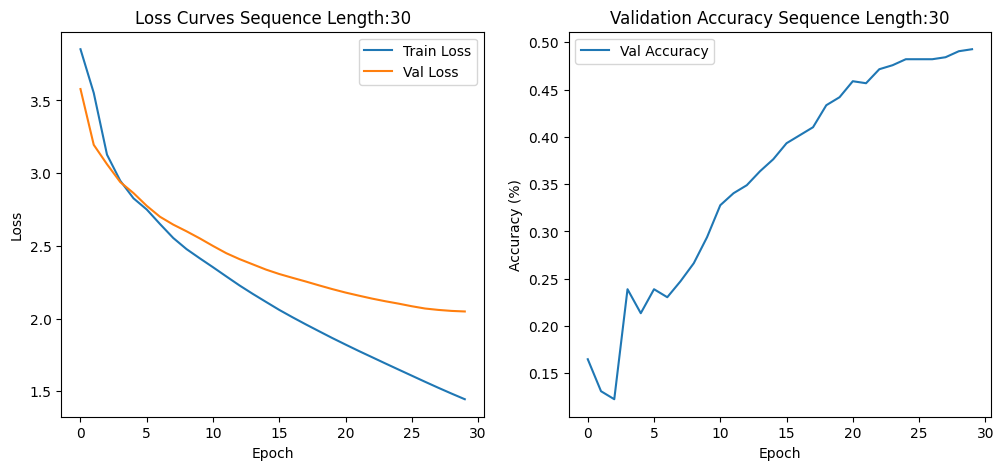

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 34]                   --
├─Embedding: 1-1                         [1, 20, 100]              3,400
├─RNN: 1-2                               [1, 20, 100]              20,200
├─Linear: 1-3                            [1, 34]                   3,434
Total params: 27,034
Trainable params: 27,034
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.11
Estimated Total Size (MB): 0.14

In [255]:
run("LSTM")
summary(model, input_size = (1,20), dtypes=[torch.long])